In [5]:
# Autoencoder for Image Denoising using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary

In [4]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Transform: Normalize and convert to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

In [6]:
# Load MNIST dataset
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.94MB/s]


In [7]:

# Add noise to images
def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)

In [9]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 12)  # Latent dimension
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(12, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Output pixels are between 0 and 1
        )

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten the image
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(x.size(0), 1, 28, 28) # Reshape back to image
        return x

In [11]:
model = DenoisingAutoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Print model summary
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]         100,480
              ReLU-2                  [-1, 128]               0
            Linear-3                   [-1, 64]           8,256
              ReLU-4                   [-1, 64]               0
            Linear-5                   [-1, 12]             780
            Linear-6                   [-1, 64]             832
              ReLU-7                   [-1, 64]               0
            Linear-8                  [-1, 128]           8,320
              ReLU-9                  [-1, 128]               0
           Linear-10                  [-1, 784]         101,136
          Sigmoid-11                  [-1, 784]               0
Total params: 219,804
Trainable params: 219,804
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [13]:
def train(model, loader, criterion, optimizer, epochs=5):
    model.train() # Set the model to training mode
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_idx, (data, _) in enumerate(loader):
            data = data.to(device)
            noisy_data = add_noise(data) # Add noise to the input images

            optimizer.zero_grad()
            outputs = model(noisy_data)
            loss = criterion(outputs, data) # Compare output with original data
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if batch_idx % 100 == 0: # Print loss every 100 batches
                print(f'Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}')
        print(f'Epoch {epoch+1} finished, Average Loss: {running_loss/len(loader):.4f}')

In [17]:
# Evaluate and visualize
def visualize_denoising(model, loader, num_images=10):
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images).to(device)
            outputs = model(noisy_images)
            break

    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    print("Name: DHARSHINI V")
    print("Register Number:  212223040038")
    plt.figure(figsize=(18, 6))
    for i in range(num_images):
        # Original
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title("Original")
        plt.axis("off")

        # Noisy
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(noisy_images[i].squeeze(), cmap='gray')
        ax.set_title("Noisy")
        plt.axis("off")
         # Denoised
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
        plt.imshow(outputs[i].squeeze(), cmap='gray')
        ax.set_title("Denoised")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Epoch 1/5, Batch 0/469, Loss: 0.1403
Epoch 1/5, Batch 100/469, Loss: 0.1340
Epoch 1/5, Batch 200/469, Loss: 0.1303
Epoch 1/5, Batch 300/469, Loss: 0.1406
Epoch 1/5, Batch 400/469, Loss: 0.1429
Epoch 1 finished, Average Loss: 0.1393
Epoch 2/5, Batch 0/469, Loss: 0.1411
Epoch 2/5, Batch 100/469, Loss: 0.1372
Epoch 2/5, Batch 200/469, Loss: 0.1372
Epoch 2/5, Batch 300/469, Loss: 0.1346
Epoch 2/5, Batch 400/469, Loss: 0.1361
Epoch 2 finished, Average Loss: 0.1375
Epoch 3/5, Batch 0/469, Loss: 0.1326
Epoch 3/5, Batch 100/469, Loss: 0.1309
Epoch 3/5, Batch 200/469, Loss: 0.1449
Epoch 3/5, Batch 300/469, Loss: 0.1344
Epoch 3/5, Batch 400/469, Loss: 0.1406
Epoch 3 finished, Average Loss: 0.1360
Epoch 4/5, Batch 0/469, Loss: 0.1334
Epoch 4/5, Batch 100/469, Loss: 0.1376
Epoch 4/5, Batch 200/469, Loss: 0.1365
Epoch 4/5, Batch 300/469, Loss: 0.1337
Epoch 4/5, Batch 400/469, Loss: 0.1316
Epoch 4 finished, Average Loss: 0.1348
Epoch 5/5, Batch 0/469, Loss: 0.1343
Epoch 5/5, Batch 100/469, Loss: 0.1

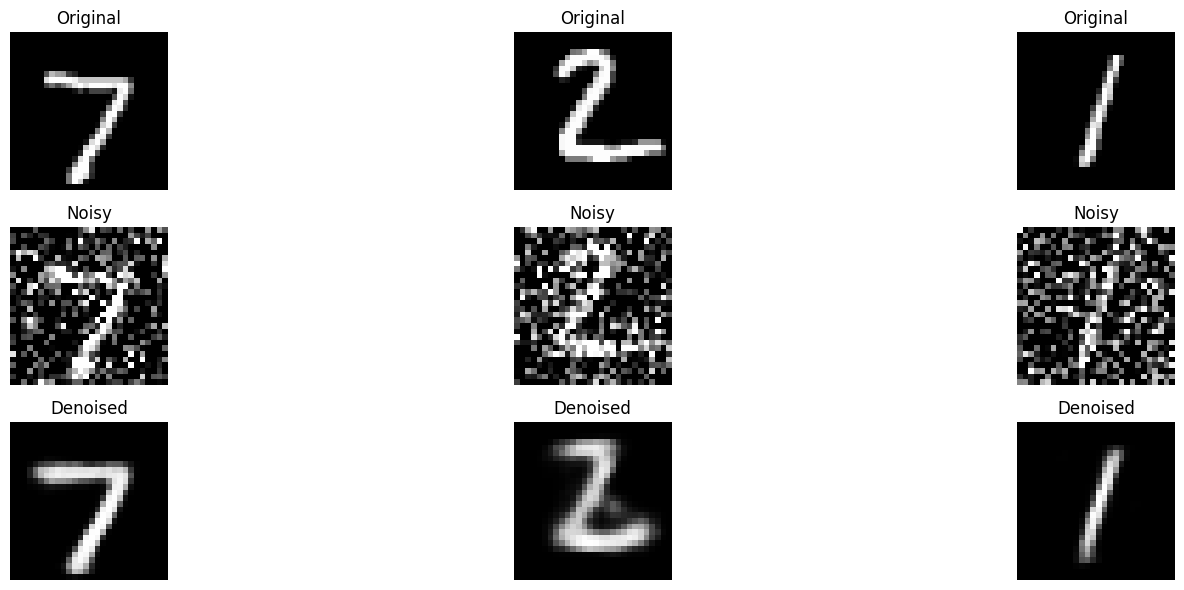

In [19]:
# Run training and visualization
train(model, train_loader, criterion, optimizer, epochs=5)
visualize_denoising(model, test_loader, num_images=3)